# Questão 2


## Letra A

O objetivo é mostrar que $R_{X, s} \circ L_{X} = id_{P_d}$, ou seja, para todo $p \in P_{d}$, $R_{X, d}(L_{X}(p)) = p$.

Por definição, $R_{X, s}(L_{X}(p))$ é igual ao polinômio $q \in P_{d}$ que minimiza $\|L_{X}(q) - L_{X}(p)\|_2^2$. Sabemos que $\|L_{X}(q) - L_{X}(p)\|_2^2 \geq 0$ para todo $p$ e $q$. Então, o valor de $\|L_{X}(q) - L_{X}(p)\|_2^2$ é minimizado quando ocorre a igualdade:

$$\|L_{X}(q) - L_{X}(p)\|_2^2 = 0 \iff \|L_{X}(q) - L_{X}(p)\|_2 = 0$$

Pela definição de norma, temos $\|L_{X}(q) - L_{X}(p)\|_2 = 0 \iff L_{X}(q) - L_{X}(p) = 0$. Conforme demonstrado na questão 1 item d, o funcional de avaliação $L_{X}$ é injetivo (posto completo com $m \geq d + 1$), dessa forma $L_{X}(q) - L_{X}(p) = 0 \iff L_{X}(q) = L_{X}(p) \iff q = p$. Portanto, $R_{X, d}(L_{X}(p)) = p$ para todo $p \in P_{d}$. 

Provamos então que $R_{X, d}$ é uma inversa a esquerda de $L_{X}$.



## Letra B

O objetivo é se convencer de que $R_{X, d}$ é uma transformação linear. 

Qualquer $p \in P_{d}$ pode ser escrito na base canônica dos polinômios como $\sum_{i = 0}^{d} \alpha_{i}x^{i}$, então o funcional de avaliação $L_{X}(p)$ equivale a:

$$
L_{X}(p) =
\begin{bmatrix}
p(x_1)\\
p(x_2)\\
\vdots\\
p(x_m)
\end{bmatrix} =
\begin{bmatrix}
\sum_{i = 0}^{d} \alpha_{i}x_1^{i}\\
\sum_{i = 0}^{d} \alpha_{i}x_2^{i}\\
\vdots\\
\sum_{i = 0}^{d} \alpha_{i}x_m^{i}
\end{bmatrix}
$$

Note que podemos compreender cada somatório como um produto interno entre uma linha $(1, x_i, x_i^2, x_i^3, \dots, x_i^d)$ pelo vetor coluna $(\alpha_0, \alpha_1, \alpha_2, \dots, \alpha_d)^{T}$, então é intuitivo visualizar $L_{X}(p)$ como o resultado de uma multiplicação de uma matriz com $m$ linhas em que a i-ésima linha equivale ao vetor $(1, x_i, x_i^2, x_i^3, \dots, x_i^d)$, pelo vetor coluna $(\alpha_0, \alpha_1, \alpha_2, \dots, \alpha_d)^{T}$. Logo:

$$
L_{X}(p) =
\begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^d \\
1 & x_2 & x_2^2 & \cdots & x_2^d \\
1 & x_3 & x_3^2 & \cdots & x_3^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_m & x_m^2 & \cdots & x_m^d
\end{bmatrix}
.
\begin{bmatrix}
\alpha_0\\
\alpha_1\\
\alpha_2\\
\vdots\\
\alpha_d
\end{bmatrix}
$$

A matriz descrita acima é a matriz de Vandermonde ($V$) e o vetor, que chamaremos de $a$, equivale ao vetor de coeficientes do polinômio $p$ escrito na base canônica, portanto:

$$L_{X}(p) = Va$$

Dessa forma, minimizar $\|L_{X}(p) - b\|_2^2$ sobre $p \in P_{d}$ para determinar $R_{X, d}$ equivale a minimizar $\|Va - b\|_2^2$ sobre $a \in \mathbb{R}^{d+1}$. A solução desse problema equivalente é a pseudoinversa de V:

$$a = V^{+}b = (V^{*}V)^{-1}V^{*}b$$

Observação:
- $V^{*}V$ é invertível pelo seguinte teorema: $A^{*}A$ possui inversa $\iff$ $A$ é injetiva. Como no item d da questão 1 provamos que, para $m \geq d + 1$ $V$ é injetiva, $V^{*}V$ é invertível;

Dessa forma, $R_{X, d}(b)$ (encontrar a solução dos mínimos quadrados) nessa base fixada corresponde a aplicar a matriz $V^{+}$ ao vetor $b$. Como $V^{+}$ é uma matriz e toda transformação dada por uma matriz é linear, a aplicação $b \mapsto V^{+}b$ é linear, e, portanto, $R_{X, d}$ é uma **transformação linear**.

## Letra C

## Letra D

Funções úteis:

In [4]:
using LinearAlgebra
using Plots

function vander(pts, d)
    # Vandermonde: cada linha é [1, x, x^2, ..., x^d]
    V = zeros(length(pts), d+1)

    for (id, x) in enumerate(pts)
        for k in 0:d
            V[id, k+1] = x^k
        end
    end

    return V
end

function rx_matrix(V)
    return pinv(V)
end

function line_plot(X, y_1, key_1, y_2, key_2, variable, title)

    p1 = plot(X, y_1, 
        xlabel="$variable", ylabel="$key_1", 
        title="Variação em $key_1", 
        color= :blue,
        yscale= :log, xscale=:identity,

        titlefontsize=14,
        guidefontsize=12,
        tickfontsize=10,
        legend=false
    )

    p2 = plot(X, y_2, 
        xlabel="$variable", ylabel="$key_2", 
        title="Variação em $key_2", 
        color= :red,
        yscale= :log, xscale =:identity,

        titlefontsize=14,
        guidefontsize=12,
        tickfontsize=10,
        legend=false
    )

    plot(p1, p2, layout=(2, 1), 
        plot_title="\n$title", 
        size=(900, 700), 
        plot_titlevspan =0.12,
        margin=5Plots.mm,
        top_margin=5Plots.mm
    )

end


line_plot (generic function with 1 method)

┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots C:\Users\Lenovo\.julia\packages\Plots\GIume\src\args.jl:1590
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots C:\Users\Lenovo\.julia\packages\Plots\GIume\src\args.jl:1590


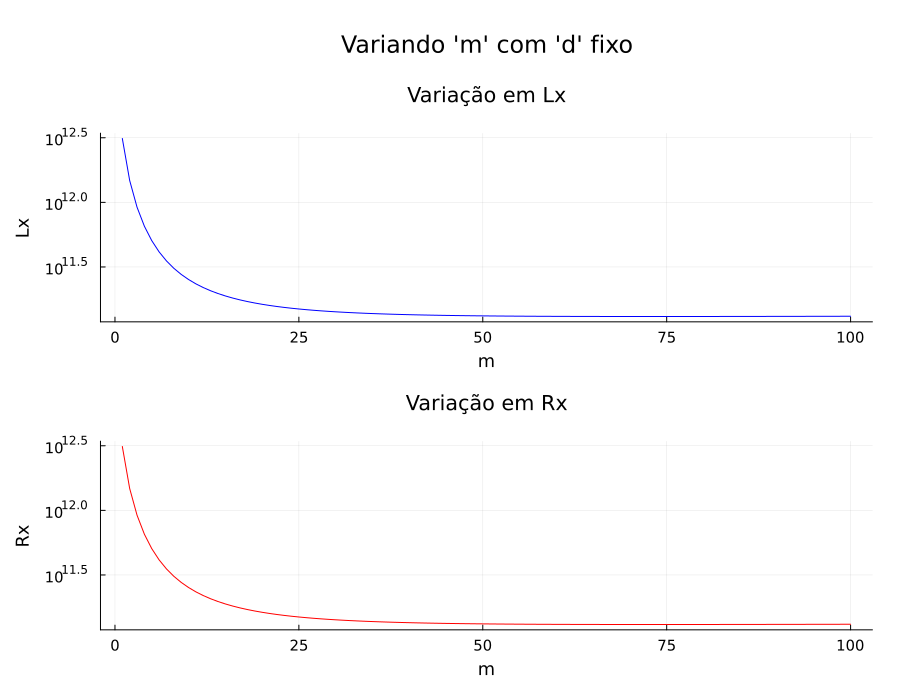

In [5]:

m_values = 1:100
d_values = 1:30

function partial_variation(m_values, d_values)

    m_behavior = Dict("Lx" => zeros(length(m_values)), "Rx" => zeros(length(m_values)))
    d_behavior = Dict("Lx" => zeros(length(d_values)), "Rx" => zeros(length(d_values)))

    # Variando m com d fixo

    # Fixaremos m em 50 para variar d
    X = collect(range(0, 1, length=50))

    for d in d_values
        Lx = vander(X, d)
        Rx = rx_matrix(Lx)

        d_behavior["Lx"][d] = cond(Lx)
        d_behavior["Rx"][d] = cond(Rx)
    end

    # Variando m com d fixo
    for m in m_values

        # Fixaremos d na média
        d = 15
        X = collect(range(0, 1, m+d))

        Lx = vander(X, d)
        Rx = rx_matrix(Lx)

        m_behavior["Lx"][m] = cond(Lx)
        m_behavior["Rx"][m] = cond(Rx)

    end

    
    line_plot(m_values, m_behavior["Lx"], "Lx", m_behavior["Rx"], "Rx", "m", "Variando 'm' com 'd' fixo")

    # return d_behavior, m_behavior
    
end

partial_variation(m_values, d_values)


In [6]:

max_iteration = 100
d = 0

function complete_variation(d, max_iteration)
    
    m_d_behavior = Dict(
            "Lx" => zeros(max_iteration), 
            "Rx" => zeros(max_iteration), 
            "m" => zeros(max_iteration),
            "d" => zeros(max_iteration))

    for iter in 1:max_iteration
        
        # m = d + 5 para sempre garantir que m >= d + 1
        X = rand(d + 5)

        Lx = vander(X, d + iter)
        Rx = rx_matrix(Lx)

        m_d_behavior["m"][iter] = d + 5
        m_d_behavior["d"][iter] = d
        m_d_behavior["Lx"][iter] = cond(Lx)
        m_d_behavior["Rx"][iter] = cond(Rx)

        # println("m:", d+5)
        # println("d:", d)
        # println("cond(Lx):", m_d_behavior["Lx"][iter])
        # println("cond(Rx):", m_d_behavior["Rx"][iter])

        d += 1

    end

    return m_d_behavior
    
end

complete_variation(0, 100)

Dict{String, Vector{Float64}} with 4 entries:
  "Lx" => [4.98128, 1518.43, 47710.3, 5.5429e7, 5.9301e7, 2.87291e10, 5.65383e8…
  "m"  => [5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0  …  95.0, 96.0…
  "Rx" => [4.98128, 1518.43, 47710.3, 5.5429e7, 5.9301e7, 2.87291e10, 5.65383e8…
  "d"  => [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0  …  90.0, 91.0, 92.…

## Letra E

Funções úteis:

In [7]:
# Calcula denomidadores
function lagrange_denominators(X)
    m = length(X)
    denominators = zeros(m)
    for j in 1:m
        den = 1.0
        for k in 1:m
            if k != j
                den *= (X[j] - X[k])
            end
        end
        denominators[j] = den
    end
    return denominators
end

# Calcula numerador e polinômio final, um polinômio por vez
function lagrange_eval(X, denominators, j, y)
    m = length(X)
    num = 1.0
    for k in 1:m
        if k != j
            num *= (y - X[k])
        end
    end
    return num / denominators[j]
end

# Calcula a matriz Lambda (L_Y na base de Lagarange)
function lagrange_matrix(X, Y)
    m = length(X)
    n = length(Y)
    dens = lagrange_denominators(X)
    Lambda = zeros(n, m)
    for (i, y) in enumerate(Y)
        for j in 1:m
            Lambda[i, j] = lagrange_eval(X, dens, j, y)
        end
    end
    return Lambda
end


lagrange_matrix (generic function with 1 method)

# Questão 3

## Letra D

### Comentários:

Lembrete:
- $(R_{X,d})_{(d+1) \times m}$
- $(L_X)_{m \times (d+1)}$
- $(L_Y)_{n \times (d+1)}$
- $(L_y \circ R_{X,d})_{n \times m}$

-> Observação sobre o código abaixo na base de Lagrange:

* Caso 1: $m = d+1$

A composta $L_{Y} \circ R_{X, d}$ é uma transformação linear de $\mathbb{R^m} \rightarrow \mathbb{R^n}$, quando representamos essa composta por uma matriz temos uma matriz $n \times m$. Quando $m = d+1$ temos o seguinte:

1. $R_{X, d}$ na base de Lagrange é a identidade $(d + 1) \times (d+1)$ pois pelo item a da questão 1 $R_{X, d} \circ L_X = I$ e $L_x$ na base de Lagrande é a identidade (deve ser demonstrado, vimos um pouco no item g da 1) e a inversa da identidade é a identidade.
2. $L_Y$ na base de Lagrange é uma matriz que nós chamaremos de $\Lambda$ de tamanho $n \times m = n \times (d + 1)$.
3. A composta $L_Y \circ R_{X, d} = L_Y(R_{X, d}) = \Lambda . I = \Lambda$

* Caso 2: $m > d+1$

Na base canônica já conhecemos a matriz, vejamos na base de lagrange. A matriz da composta é dada pela multiplicação de $\Lambda$ (matriz de $L_Y$ na base de Lagrange) multiplicada pela matriz da transformação $R_{X,d}$ na base de Lagrange:

$$M_{lagrande} = \Lambda . R_{X, d}^{Lag}$$

O que significa representar $R_{X,d}$ na base de Lagrange? $R_{X,d}$ recebe um vetor $b \in \mathbb{R^m}$ e devolve um polinômio $p \in P_d$. Para representar isso como uma matriz precisamos expressar $p$ em coordenadas, que dependem da base escolhida. 

Na base de Lagrange $p = c_1p_1 + c_2p_2 + \dots + c_{d+1}p_{d+1}$, então as coordenadas são $c = (c_1, c_2, c_3, \dots, c_{d+1})$. Precisamos encontrar $c$ tal que o polinômio $\sum_{j=1}^{d+1}c_jp_j$ é o que melhor se ajusta a $b$, para isso queremos minimizar a distância entre os valores do polinômio nos pontos de $X$ e os valores observados b:

$$\min_{c}\|p(X) - b\|_2^2 
= 
\min_{c} 
\left\|\begin{bmatrix}
p(x_1)\\
p(x_2)\\
\vdots\\
p(x_m)
\end{bmatrix}
-
\begin{bmatrix}
b_1\\
b_2\\
\vdots\\
b_m
\end{bmatrix}
\right\|_2^2 $$

Dado que estamos buscando minimizar em relação as coordenadas descritas por $c$ precisamos escrever $p(x_i)$ em função das coordenadas $c$ e avaliar $p$ (ou seja, encontrar $c$ que descreve $p$) nos pontos $X$ é exatamente:

$$p(x_i) = \sum_{j=1}^{d+1}c_jp_j(x_i)$$

Empilhando isso  para todos os $x_i$ temos:

$$\begin{bmatrix}
p(x_1)\\
p(x_2)\\
\vdots\\
p(x_m)
\end{bmatrix}
=
\begin{bmatrix}
p_1(x_1) & p_2(x_1) & p_3(x_1) & \cdots & p_{d+1}(x_1)\\
p_1(x_2) & p_2(x_2) & p_3(x_2) & \cdots & p_{d+1}(x_2)\\
p_1(x_3) & p_2(x_3) & p_3(x_3) & \cdots & p_{d+1}(x_3)\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
p_1(x_m) & p_2(x_m) & p_3(x_m) & \cdots & p_{d+1}(x_m)\\
\end{bmatrix}
.
\begin{bmatrix}
c_1\\
c_2\\
\vdots\\
c_{d+1}
\end{bmatrix}
=
L_{X}^{Lag} . c
$$

* Note que essa matriz $L_{X}^{Lag}$ é a identidade nas primiras $d+1$ linhas (pela definição de $p_i$, até $x_d+1$ temos a identidade), a partir da linha $d+1$ temos valores calculáveis, mas não determinados analiticamente.

Nosso problema agora é $min_{c}\|L_{X}^{Lag} . c - b\|_2^2$, caímos novamente no problema de mínimos quadrados convencional, cuja solução ($R_{X,d}$) é $c = (L_X^{Lag})^{+}b$. Portanto, representar $R_{X,d}$ na base de Lagrange é o mesmo que resolver esse problema de mínimos quadrados, logo, $R_{X,d}^{Lag} = (L_X^{Lag})^{+}$, dado que para todo $b$ que passarmos como "input" para $R_{X,d}^{Lag}$ a solução é $(L_X^{Lag})^{+}b$.



Comparação entre base canônica e base de Lagrange
(m,n,d)          κ canônica   κ Lagrange   SVs iguais?    Mats iguais?  
------------------------------------------------------------------------------------------
(6,20,5)         3.07e+00     3.07e+00     true           true          
(10,20,5)        1.72e+16     5.34e+15     true           true          
(20,20,5)        4.86e+17     4.31e+16     false          false         
(50,20,5)        3.32e+16     4.21e+14     false          false         
(6,50,5)         3.99e+00     3.99e+00     true           true          
(6,100,5)        4.39e+00     4.39e+00     true           true          
(6,20,2)         3.27e+16     1.18e+16     true           true          
(6,20,4)         6.13e+15     8.12e+15     true           true          
(21,20,20)       1.43e+04     1.43e+04     false          false         
(31,20,30)       9.58e+04     9.58e+04     false          false         
Comparação entre base canônica e base de Lagrange
(m,n,d

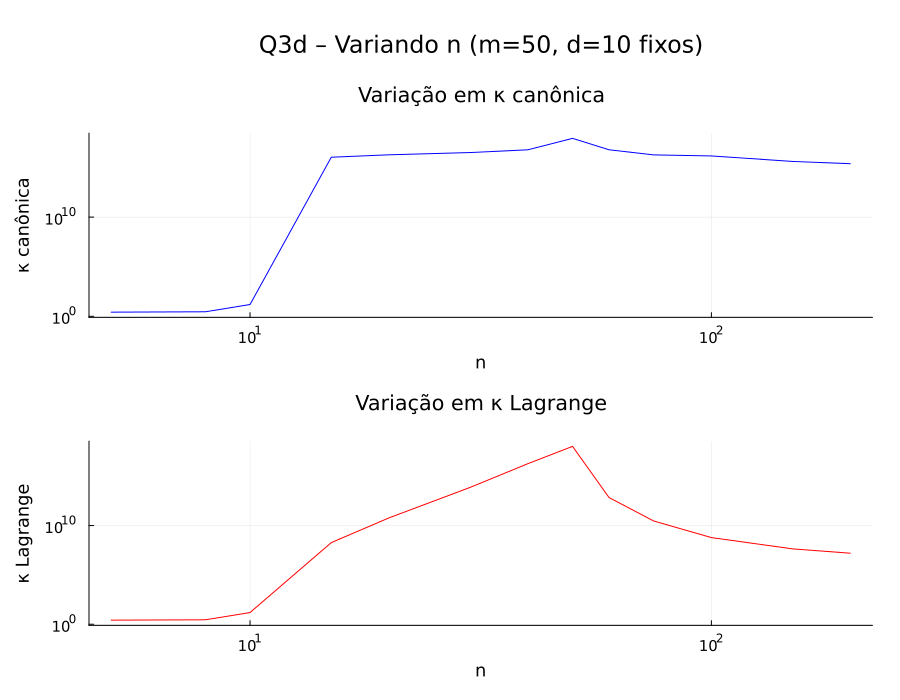

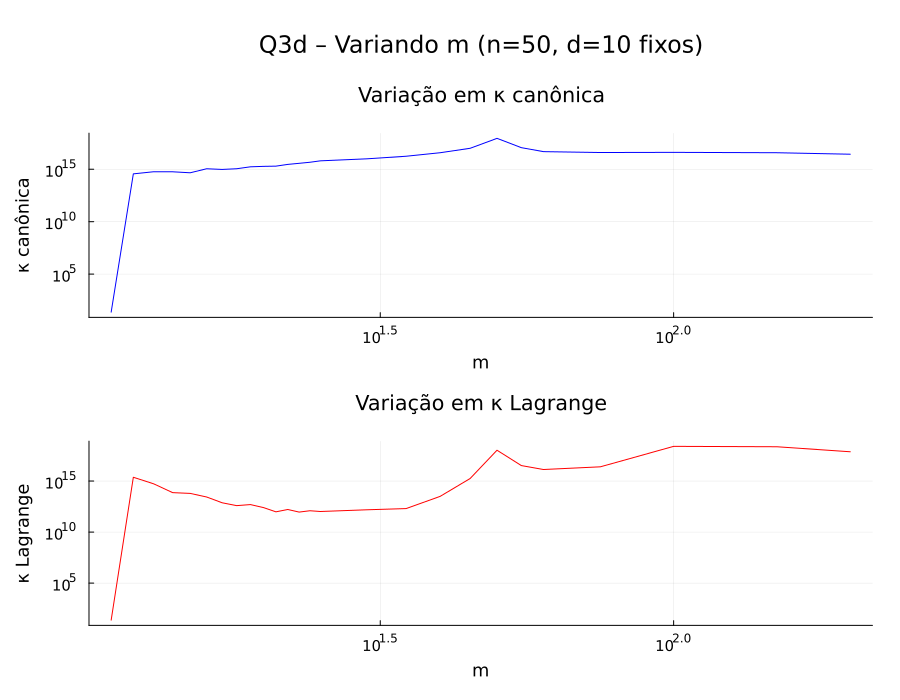

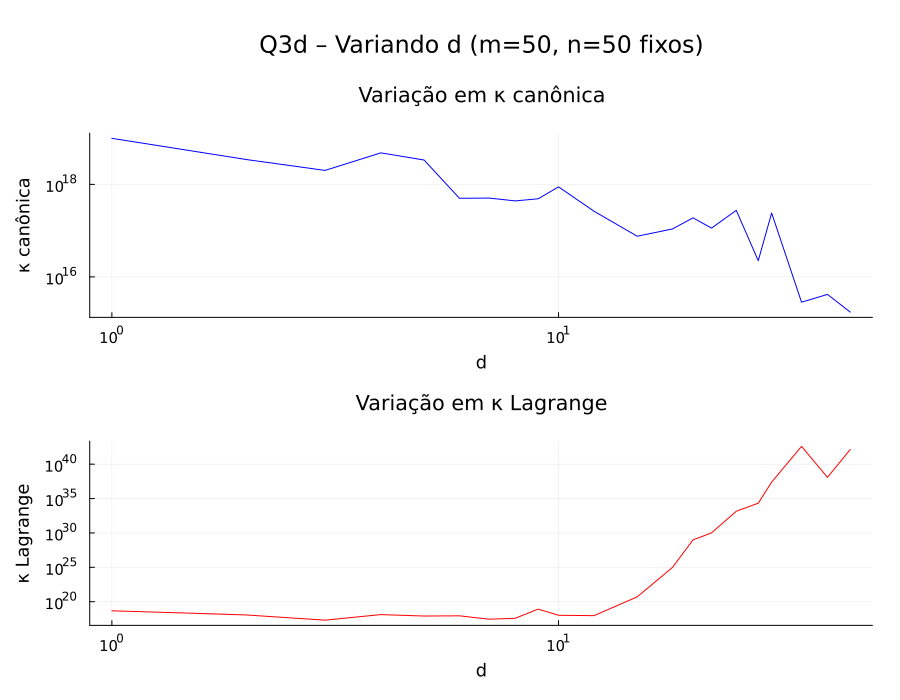

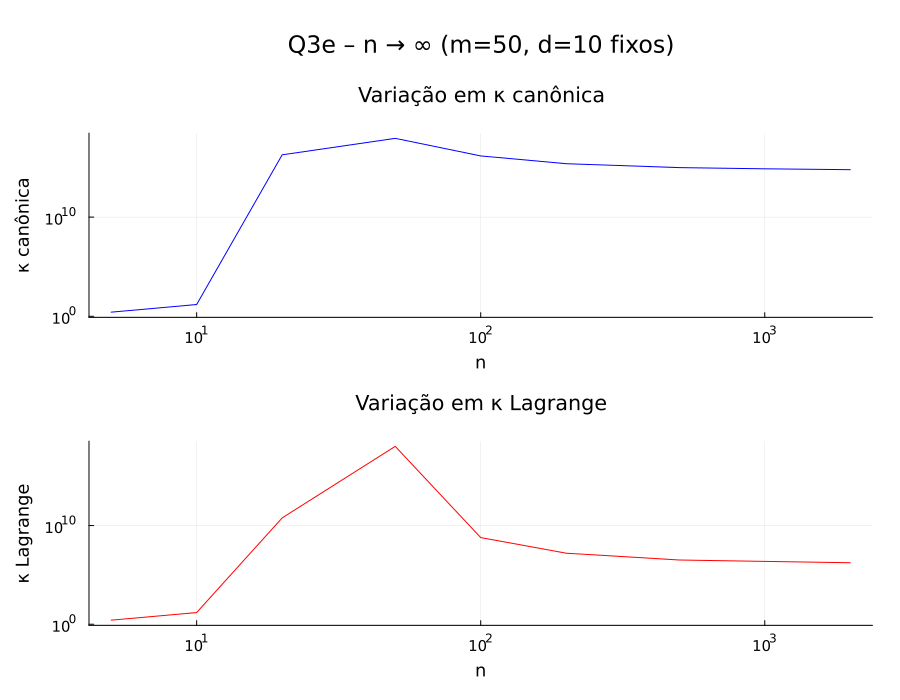

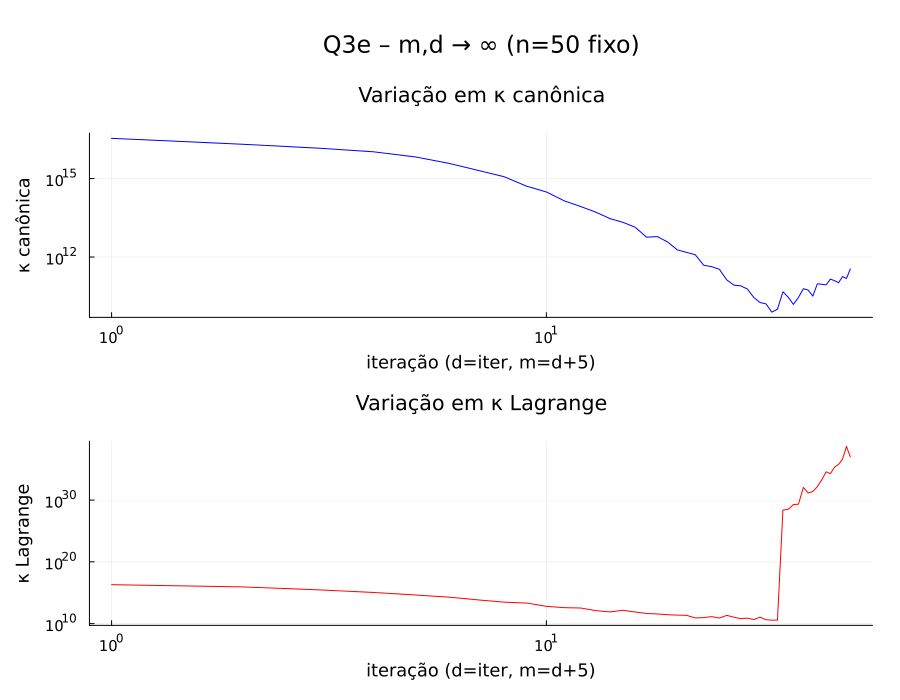

In [ ]:
using Printf

# PLOTS AINDA NÃO ESTÃO TERMINADOS


# Realiza as compostas para cada trio m, n, d
function compute_composition(m, n, d)
    try
        X = collect(range(-1, 1, length=m))
        Y = collect(range(-1, 1, length=n))
        X_lag = X[1:d+1]  # primeiros d+1 pontos para base de Lagrange, podemos ter mais

        # Base canônica: não se preocupa com m > d+1 pois o polinômio já existe, só é ajustado
        Vx = vander(X, d)   # L_X que iremos "inverter" para achar R_X,d
        Vy = vander(Y, d)   # L_Y
        M_can = Vy * rx_matrix(Vx)  # Composta L_y(R_{x,d})
        sv_can = svdvals(M_can)

        # Base de Lagrange: polinômios são construídos a partir dos pontos, se usar m o grau > d
        Lx_lag = lagrange_matrix(X_lag, X)   # L_X que iremos "inverter" para achar R_X,d
        Rx_lag = rx_matrix(Lx_lag)                # R_{x,d}
        Lambda = lagrange_matrix(X_lag, Y)   # L_Y (avaliação dos polinômios construidos por X nos pontos de Y)
        M_lag = Lambda * Rx_lag         # Composta L_y(R_{x,d})
        sv_lag = svdvals(M_lag)

        # Necessário, explicar por que
        if isempty(sv_can) || isempty(sv_lag)
            return nothing
        end

        k_can = sv_can[1]/sv_can[end]
        k_lag = sv_lag[1]/sv_lag[end]

        is_equal_matrix = isapprox(M_can, M_lag, atol=1e-12)
        is_equal_svs = isapprox(sv_can, sv_lag, atol=1e-12)

        return (M_can, M_lag, sv_can, sv_lag, k_can, k_lag, is_equal_matrix, is_equal_svs)
    catch e
        return nothing
    end
end

# ============================================================
# Tabela de comparação de SV's e matrizes
# ============================================================

# talvez possa retirar os condicionamentos já que verei depois
function comparing_table(configs)
    println("=" ^ 90)
    println("Comparação entre base canônica e base de Lagrange")
    println("=" ^ 90)
    println(@sprintf("%-16s %-12s %-12s %-14s %-14s",
        "(m,n,d)", "κ canônica", "κ Lagrange", "SVs iguais?", "Mats iguais?"))
    println("-" ^ 90)

    for (m, n, d) in configs
        res = compute_composition(m, n, d)
        if isnothing(res)
            println(@sprintf("%-16s %s", "($m,$n,$d)", "erro/indefinido"))
            continue
        end
        _, _, _, _, k_can, k_lag, mat_ok, sv_ok = res
        println(@sprintf("%-16s %-12.2e %-12.2e %-14s %-14s",
            "($m,$n,$d)", k_can, k_lag, string(sv_ok), string(mat_ok)))
    end
    println("=" ^ 90)
end

# ====================================================================
# Funções de variação de parâmetros para comparação de condicionamento
# ====================================================================

# Variando n com m e d fixos
function n_variation(m_fixed, n_values, d_fixed)
    k_can = zeros(length(n_values))
    k_lag = zeros(length(n_values))
    for (i,n) in enumerate(n_values)
        res = compute_composition(m_fixed, n, d_fixed)
        if isnothing(res)
            k_can[i] = NaN
            k_lag[i] = NaN
        else 
            k_can[i] = res[5]
            k_lag[i] = res[6]
        end
    end
    return k_can, k_lag
end

# Variando m com n e d fixos
function m_variation(m_values, n_fixed, d_fixed)
    k_can = zeros(length(m_values))
    k_lag = zeros(length(m_values))
    for (i,m) in enumerate(m_values)
        if m < (d_fixed + 1)
            k_can[i] = NaN
            k_lag[i] = NaN
            continue
        end
        res = compute_composition(m, n_fixed, d_fixed)
        if isnothing(res)
            k_can[i] = NaN
            k_lag[i] = NaN
        else 
            k_can[i] = res[5]
            k_lag[i] = res[6]
        end
    end
    return k_can, k_lag
end

# Variando d com m e n fixos
function d_variation(m_fixed, n_fixed, d_values)
    k_can = zeros(length(d_values))
    k_lag = zeros(length(d_values))
    for (i,d) in enumerate(d_values)
        if m_fixed < (d + 1)
            k_can[i] = NaN
            k_lag[i] = NaN
            continue
        end
        res = compute_composition(m_fixed, n_fixed, d)
        if isnothing(res)
            k_can[i] = NaN
            k_lag[i] = NaN
        else 
            k_can[i] = res[5]
            k_lag[i] = res[6]
        end
    end
    return k_can, k_lag
end

# m e d crescem juntos (m = d + 5), n fixo
function md_variation(n_fixed, max_iter)
    k_can = fill(NaN, max_iter)
    k_lag = fill(NaN, max_iter)
    for iter in 1:max_iter
        d = iter
        m = d + 5
        res = compute_composition(m, n_fixed, d)
        if !isnothing(res)
            k_can[iter] = res[5]
            k_lag[iter] = res[6]
        end
    end
    return k_can, k_lag
end


# ============================================================
# Função plotagem
# ============================================================


function modified_line_plot(X, y_1, key_1, y_2, key_2, variable, title, filename=nothing)

    p1 = plot(X, y_1, 
        xlabel="$variable", ylabel="$key_1", 
        title="Variação em $key_1", 
        color= :blue,
        yscale= :log10, xscale=:identity,

        titlefontsize=14,
        guidefontsize=12,
        tickfontsize=10,
        legend=false
    )

    p2 = plot(X, y_2, 
        xlabel="$variable", ylabel="$key_2", 
        title="Variação em $key_2", 
        color= :red,
        yscale= :log10, xscale =:identity,

        titlefontsize=14,
        guidefontsize=12,
        tickfontsize=10,
        legend=false
    )

    p = plot(p1, p2, layout=(2, 1), 
        plot_title="\n$title", 
        size=(900, 700), 
        plot_titlevspan =0.12,
        margin=5Plots.mm,
        top_margin=5Plots.mm
    )

    if !isnothing(filename)
        savefig(p, filename)
    end
    return p
end


# ============================================================
# Função orquestradora
# ============================================================

function execute()
    # Tabela de matrizes
    configs_d = [
    (6,  20,  5),
    (10, 20,  5),
    (20, 20,  5),
    (50, 20,  5),
    (6,  50,  5),
    (6, 100,  5),
    (6,  20,  2),
    (6,  20,  4),
    (21, 20, 20),
    (31, 20, 30),
    ]
    comparing_table(configs_d)

    # Isso vai mostrar a transição m=d+1 (estável) → m>>d+1 (divergência numérica)
    configs_plot = [(m, 30, 5) for m in 6:2:50]
    comparing_table(configs_plot)

    # Valores de m, n e d, crescimento e comparação
    n_vals = [5, 8, 10, 15, 20, 30, 40, 50, 60, 75, 100, 150, 200]
    m_vals = vcat(11:1:25, 30:5:60, 75, 100, 150, 200)
    d_vals = vcat(1:1:10, 12, 15, 18, 20, 22, 25, 28, 30, 35, 40, 45)

    k_can_n, k_lag_n = n_variation(50, n_vals, 10)
    k_can_m, k_lag_m = m_variation(m_vals, 50, 10)
    k_can_d, k_lag_d = d_variation(50, 50, d_vals)

    display(modified_line_plot(n_vals, k_can_n, "κ canônica", k_lag_n, "κ Lagrange", "n",
    "Q3d – Variando n (m=50, d=10 fixos)", "plot_n.png"))

    display(modified_line_plot(m_vals, k_can_m, "κ canônica", k_lag_m, "κ Lagrange", "m",
    "Q3d – Variando m (n=50, d=10 fixos)", "plot_m.png"))

    display(modified_line_plot(d_vals, k_can_d, "κ canônica", k_lag_d, "κ Lagrange", "d",
    "Q3d – Variando d (m=50, n=50 fixos)", "plot_d.png"))

    # Parâmetros tendendo ao infinito
    n_vals_e = [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
    iter_vals = 1:50

    k_can_n_e, k_lag_n_e = n_variation(50, n_vals_e, 10)
    k_can_md, k_lag_md = md_variation(200, 50)

    display(modified_line_plot(n_vals_e, k_can_n_e, "κ canônica", k_lag_n_e, "κ Lagrange", "n",
    "Q3e – n → ∞ (m=50, d=10 fixos)", "plot_n_infty.png"))

    display(modified_line_plot(collect(iter_vals), k_can_md, "κ canônica", k_lag_md, "κ Lagrange",
    "iteração (d=iter, m=d+5)",
    "Q3e – m,d → ∞ (n=50 fixo)", "plot_md.png"))
end

execute()